<a href="https://colab.research.google.com/github/thimarArda/BinX_AI_-_ML_Training/blob/main/Week8_NLP_and_ComputerVision/Day%202%20%E2%80%94%20Text%20Representation%20TF-IDF%20%26%20Embeddings/Day_2_%E2%80%94_Text_Representation_TF_IDF_%26_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day 2 — Text Representation: TF-IDF & Embeddings



---



# Introduction




Yesterday, We learned how to preprocess text by cleaning it and tokenizing it. However, machine learning models cannot work directly with text. The next step in an NLP pipeline is to convert the processed text into numerical representations that a model can understand.

There are several ways to represent text numerically. Two important approaches are **TF-IDF** and **word embeddings**. TF-IDF focuses mainly on how important a word is within a collection of documents, while word embeddings try to capture relationships and meaning between words.

In this session, I will learn how both approaches work, apply TF-IDF to a small text dataset, explore word embeddings, and compare the advantages and limitations of each representation.



---





# Section 1:  From Text to Numbers





After preprocessing, text still consists of words and characters. Machine learning algorithms require numerical input, so we need a method for converting text into vectors.

There are two main families of text representation:

* **Frequency-based representations**, such as Bag-of-Words and TF-IDF.
* **Embedding-based representations**, where words are represented as dense numerical vectors that capture semantic relationships.

The choice of representation depends on the problem. TF-IDF is simple, fast, and often provides a strong baseline, while embeddings are more useful when understanding relationships between words and their meanings is important.

The general NLP pipeline can therefore be represented as:

```text
Raw Text
   ↓
Cleaning
   ↓
Tokenization
   ↓
Text Representation
   ↓
Numerical Vectors
   ↓
Machine Learning / Deep Learning Model
```

---

# Section 2: Bag-of-Words





One of the simplest ways to convert text into numbers is the **Bag-of-Words (BoW)** approach.

Bag-of-Words creates a vocabulary containing the words found in the documents. Each document is then represented by counting how many times each vocabulary word appears.

For example:

```text
Document 1: "this movie is amazing"
Document 2: "this movie is boring"
```

The vocabulary could be:

```text
["amazing", "boring", "is", "movie", "this"]
```

The documents can then be represented using word counts.

The main limitation of Bag-of-Words is that it ignores word order and meaning. For example:

```text
"The movie was good"
"The good movie was"
```

would contain the same words even though the structure is different.

---

##: TF-IDF





**TF-IDF** stands for **Term Frequency-Inverse Document Frequency**.

Instead of simply counting words, TF-IDF gives each word a score based on how important that word is within a document and across the entire collection of documents.

TF-IDF combines two ideas:

### Term Frequency (TF)

Term Frequency measures how frequently a word appears in a particular document.

A word that appears many times in a document will generally have a higher TF value.

### Inverse Document Frequency (IDF)

Inverse Document Frequency measures how uncommon a word is across the collection of documents.

Words that appear in almost every document are less useful for distinguishing between documents, so they receive lower scores.

Words that are rare across the collection can receive higher scores.

Therefore:

> TF-IDF gives higher importance to words that are frequent in a document but relatively rare across the dataset.

For example, words such as `"the"` or `"movie"` may appear in many documents, so they are less useful for distinguishing between them. A more distinctive word such as `"masterpiece"` may receive a higher score.

---

##  Applying TF-IDF



Scikit-learn provides `TfidfVectorizer`, which can automatically convert a collection of documents into a TF-IDF matrix.

For today's exercises, I will use a small text example instead of reloading the larger dataset from yesterday. This makes it easier to inspect the vocabulary and understand the numerical values produced by TF-IDF.

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

texts = [
    "this movie was amazing and enjoyable",
    "the movie was boring and disappointing",
    "I really enjoyed this amazing movie",
    "the movie was terrible and boring"
]

texts

['this movie was amazing and enjoyable',
 'the movie was boring and disappointing',
 'I really enjoyed this amazing movie',
 'the movie was terrible and boring']

### Creating the TF-IDF Vectorizer

In [2]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(texts)

> The result is a **sparse matrix** where each row represents a document and each column represents a word from the vocabulary.

We can inspect the vocabulary using:

In [3]:
feature_names = vectorizer.get_feature_names_out()
feature_names

array(['amazing', 'and', 'boring', 'disappointing', 'enjoyable',
       'enjoyed', 'movie', 'really', 'terrible', 'the', 'this', 'was'],
      dtype=object)

### Viewing the TF-IDF Matrix




The matrix can be converted to a regular NumPy array for easier inspection:

In [4]:
X.toarray()

array([[0.43202578, 0.3497621 , 0.        , 0.        , 0.54796992,
        0.        , 0.28595344, 0.        , 0.        , 0.        ,
        0.43202578, 0.3497621 ],
       [0.        , 0.3497621 , 0.43202578, 0.54796992, 0.        ,
        0.        , 0.28595344, 0.        , 0.        , 0.43202578,
        0.        , 0.3497621 ],
       [0.42049337, 0.        , 0.        , 0.        , 0.        ,
        0.53334252, 0.27832025, 0.53334252, 0.        , 0.        ,
        0.42049337, 0.        ],
       [0.        , 0.3497621 , 0.43202578, 0.        , 0.        ,
        0.        , 0.28595344, 0.        , 0.54796992, 0.43202578,
        0.        , 0.3497621 ]])

We can also display the result as a DataFrame:

In [5]:
tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=feature_names
)

tfidf_df

,amazing,and,boring,disappointing,enjoyable,enjoyed,movie,really,terrible,the,this,was
0,0.432026,0.349762,0.000000,0.00000,0.54797,0.000000,0.285953,0.000000,0.00000,0.000000,0.432026,0.349762
1,0.000000,0.349762,0.432026,0.54797,0.00000,0.000000,0.285953,0.000000,0.00000,0.432026,0.000000,0.349762
2,0.420493,0.000000,0.000000,0.00000,0.00000,0.533343,0.278320,0.533343,0.00000,0.000000,0.420493,0.000000
3,0.000000,0.349762,0.432026,0.00000,0.00000,0.000000,0.285953,0.000000,0.54797,0.432026,0.000000,0.349762



Each row represents one document, while each column represents a word. The values represent the TF-IDF weight of that word in that document.

---


##  Understanding the TF-IDF Results




The TF-IDF matrix allows us to see which words are more important within each document.

A word that appears frequently in one document but rarely in the others will generally receive a higher score in that document.

On the other hand, words that appear across many documents will have lower IDF values and therefore lower TF-IDF scores.

This makes TF-IDF useful for tasks such as:

* Text classification
* Sentiment analysis
* Document similarity
* Search systems
* Keyword extraction

However, TF-IDF does not understand the actual meaning of words. For example, `"amazing"` and `"excellent"` are treated as completely different features even though they have similar meanings.

---

# Section 3 :  Word Embeddings





TF-IDF represents words according to their importance, but it does not capture their semantic meaning.

**Word embeddings** solve this problem by representing words as dense numerical vectors.

Instead of representing a word as simply an independent feature, an embedding places it in a multidimensional vector space.

Words with similar meanings tend to have similar vector representations.

For example:

```text
king
queen
man
woman
```
can have vectors that reflect their relationships in semantic space.

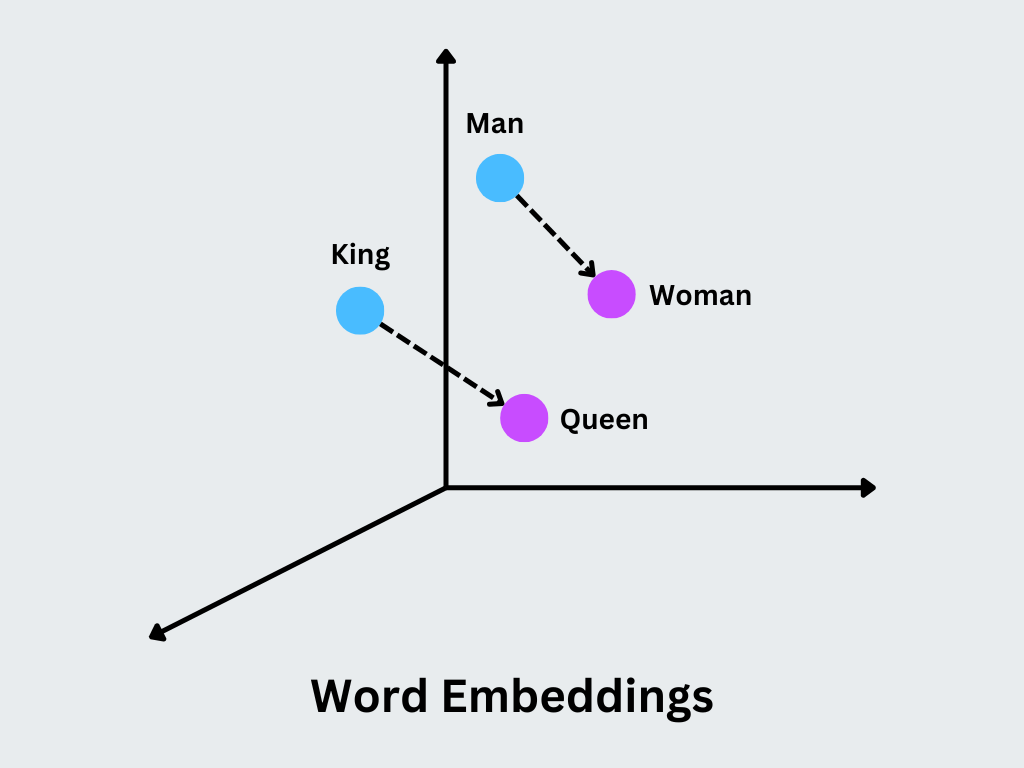



This is one of the main differences between TF-IDF and embeddings:

```text
TF-IDF:
word → importance score

Embedding:
word → dense vector representing learned relationships
```



---

## 1. Word2Vec



**Word2Vec** is one of the classic methods for learning word embeddings.

It learns word representations by looking at the contexts in which words appear.

The basic idea is that words appearing in similar contexts tend to have similar meanings.

For example, if a model frequently sees:

```text
"I drank coffee"
"I drank tea"
```

it can learn that `"coffee"` and `"tea"` have similar contextual relationships.

Word2Vec can produce vectors that allow us to measure similarity between words.

---

## 2. GloVe





**GloVe (Global Vectors for Word Representation)** is another classic word embedding method.

While Word2Vec focuses heavily on local context, GloVe uses global word co-occurrence information from a corpus.

Both methods produce dense vectors where relationships between words can be represented geometrically.

---

## 3. Semantic Geometry

One interesting property of word embeddings is that relationships between words can sometimes be represented through vector arithmetic.

A famous example is:

```text
king - man + woman ≈ queen
```

This does not mean the model literally understands the concepts in the same way a human does. But the learned vector space contains statistical patterns that can represent relationships between words.

Words that are semantically related tend to be located closer together in the vector space.

---


## **Implementation :** Exploring Word Embeddings with Word2Vec

For this exercise, we will train a small `Word2Vec` model on the example text.

First, install/import Gensim :

In [7]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 39.1 MB/s eta 0:00:00



Then import Word2Vec:

In [9]:
from gensim.models import Word2Vec

Word2Vec works with tokenized sentences, so we first tokenize our example:


In [10]:
tokenized_texts = [
    text.lower().split()
    for text in texts
]

tokenized_texts

[['this', 'movie', 'was', 'amazing', 'and', 'enjoyable'],
 ['the', 'movie', 'was', 'boring', 'and', 'disappointing'],
 ['i', 'really', 'enjoyed', 'this', 'amazing', 'movie'],
 ['the', 'movie', 'was', 'terrible', 'and', 'boring']]

Now we can train a small Word2Vec model:

In [11]:
word2vec_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=50,
    window=3,
    min_count=1,
    workers=4,
    seed=42
)


Syntax:

* `vector_size=50` means each word is represented using a 50-dimensional vector.
* `window=3` determines how much surrounding context is considered.
* `min_count=1` allows even words that appear only once to be included.
* `seed=42` makes the result more reproducible.

---

##  Viewing an Embedding

We can retrieve the vector representing a word:

In [12]:
word2vec_model.wv["movie"]

array([-1.6429963e-02,  1.0958240e-02,  6.1828587e-03, -2.4448633e-03,
       -2.6793908e-03,  1.4343915e-02, -1.6562175e-02,  7.8947209e-03,
       -1.1941221e-02, -1.6232908e-02,  1.0591579e-03,  1.9024892e-02,
        9.4300937e-03,  1.0445587e-02,  8.6990902e-03,  1.1442571e-02,
        5.2906276e-04, -1.4875455e-02,  1.3589928e-02, -1.9845630e-03,
        1.4076233e-05, -5.1680803e-03, -1.2698016e-02,  1.7070599e-02,
        1.1262698e-02,  5.7546045e-03, -3.9034272e-03,  1.2910464e-02,
        1.8171645e-03, -2.2634340e-03, -1.9816183e-03, -1.0910451e-02,
       -1.6314564e-02,  2.1833896e-03,  1.5515592e-02, -1.7447311e-02,
        1.4331651e-02,  1.3105244e-02, -8.9296130e-03,  5.2665756e-03,
       -1.3390839e-02,  1.0323508e-02,  8.0209188e-03, -5.8189631e-03,
       -1.7283201e-02,  1.8827921e-02, -2.1725011e-03,  1.5724843e-02,
        7.1167587e-03,  1.1135340e-02], dtype=float32)



The result is a dense numerical vector.

Unlike TF-IDF, where a word is represented by its importance across documents, this vector represents the word's learned position in the embedding space.

We can check its size:

In [13]:
len(word2vec_model.wv["movie"])

50



---

##  Finding Similar Words



Word embeddings can also be used to find words that are close to a particular word in the learned vector space.

For example:

In [14]:
word2vec_model.wv.most_similar("movie")

[('i', 0.1310119926929474),
 ('this', 0.044465333223342896),
 ('was', -0.013882379978895187),
 ('really', -0.018679842352867126),
 ('the', -0.02738454006612301),
 ('amazing', -0.05649303272366524),
 ('enjoyable', -0.06195279583334923),
 ('boring', -0.06604263186454773),
 ('enjoyed', -0.09824467450380325),
 ('terrible', -0.10234043002128601)]



Because this is a very small example dataset, the results will not be as meaningful as those from a large pre-trained embedding model.

This demonstrates an important point:

> Word embeddings become much more useful when they are trained on large and diverse collections of text.



---

# Section 4:  TF-IDF vs. Word Embeddings



The two approaches solve related problems but represent text differently.

| Feature                      | TF-IDF          | Word Embeddings            |
| ---------------------------- | --------------- | -------------------------- |
| Representation               | Sparse vector   | Dense vector               |
| Main idea                    | Word importance | Word meaning/relationships |
| Uses word frequency          | Yes             | Indirectly                 |
| Captures semantic similarity | No              | Yes                        |
| Considers context            | Very limited    | Yes, depending on method   |
| Easy to interpret            | Yes             | More difficult             |
| Computational cost           | Low             | Higher                     |
| Good for traditional ML      | Yes             | Sometimes                  |
| Good for deep learning       | Limited         | Yes                        |

TF-IDF is usually a strong first baseline because it is simple, fast, and easy to interpret.

Embeddings are more powerful when semantic relationships between words are important.

---

## Compare TF-IDF and Embeddings

The two representations can be summarized as follows:

```text
TF-IDF

Document
   ↓
Words
   ↓
Word importance
   ↓
Sparse numerical vector
```

```text
Word Embeddings

Words + Context
      ↓
Learned relationships
      ↓
Dense numerical vectors
      ↓
Semantic representation
```

### Question

Which representation would be more appropriate for a traditional text classification baseline?

**Answer:**

TF-IDF would usually be a strong first choice because it is simple, fast, easy to interpret, and works well with traditional machine learning algorithms.

Which representation would be more appropriate when semantic relationships between words are important?

**Answer:**

Word embeddings would generally be more appropriate because they represent words as dense vectors that can capture relationships and similarities between words.


---

# Section 5 : Contextual Embeddings




Classic Word2Vec and GloVe assign one fixed vector to each word.

This creates a problem with words that have multiple meanings.

For example:

```text
"I deposited money in the bank."

"We sat near the river bank."
```

The word `"bank"` has a different meaning in each sentence.

Traditional Word2Vec would normally use the same vector for `"bank"` in both situations.

**Contextual embeddings** solve this by generating representations that depend on the surrounding words.

Transformer models such as **BERT** can produce different representations for the same word depending on its context.

This is one reason transformer-based models are much more effective for complex NLP tasks.

The progression can therefore be viewed as:

```text
Bag-of-Words
      ↓
TF-IDF
      ↓
Word2Vec / GloVe
      ↓
Contextual Embeddings
      ↓
Transformer Models
```

---



# Section 6 : Choosing A Representation



### Scenario 1: Spam Detection

Suppose the task is to classify emails as spam or not spam.

A reasonable first approach would be:

```text
Text
 ↓
Cleaning
 ↓
TF-IDF
 ↓
Traditional ML classifier
```

TF-IDF is a good baseline because specific words and phrases can be strong indicators of spam.

### Scenario 2: Semantic Similarity

Suppose the task is to determine whether two sentences have similar meanings.

Embeddings would generally be more useful because semantic relationships are important.

### Scenario 3: Complex Context Understanding

Suppose the task requires understanding the meaning of a word based on its surrounding sentence.

Contextual embeddings from transformer models would be more suitable.

---



## Applying the Representation to a Real NLP Project

For a real text classification project, the process can be extended from the small example to the actual dataset.

The complete pipeline would look like:

```text
Raw Dataset
     ↓
Text Cleaning
     ↓
Tokenization
     ↓
Train / Validation / Test Split
     ↓
TF-IDF or Embeddings
     ↓
Model Training
     ↓
Evaluation
```

It is important to fit the TF-IDF vectorizer only on the training data when working with a real machine learning project. This prevents information from the validation or test sets from influencing the learned vocabulary and IDF values.

For example:

```python
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_val_tfidf = vectorizer.transform(X_val_text)
X_test_tfidf = vectorizer.transform(X_test_text)
```

Notice that `fit_transform()` is used only on the training data, while validation and test data use `transform()`.

---


# Section 7 : Summary




Today I learned that preprocessing is only the first part of an NLP pipeline. After cleaning and tokenizing text, the text must be converted into numerical representations before it can be used by machine learning models.

The main concepts covered were:

* **Bag-of-Words** represents text using word counts.
* **TF-IDF** improves on simple word counts by considering how important and distinctive a word is.
* **Word embeddings** represent words as dense vectors and can capture semantic relationships.
* **Word2Vec** and **GloVe** are classic embedding approaches.
* **Contextual embeddings** generate representations that depend on the surrounding context.
* **Transformers** such as BERT use contextual representations to handle more complex language relationships.

The main difference can be summarized as:

```text
TF-IDF → "How important is this word in this document?"

Embeddings → "How is this word related to other words?"

Contextual embeddings → "What does this word mean in this particular context?"
```

Therefore, TF-IDF is often an excellent starting point for traditional machine learning text classification, while embeddings and contextual embeddings become increasingly useful for semantic and deep-learning-based NLP tasks.
